***

### DL & GEN AI

### PRACTICAL 6: RNN & LSTM

***

## 1] import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,SimpleRNN,LSTM,Dense
from tensorflow.keras.callbacks import EarlyStopping

## 2] set random seed

In [2]:
SEED=42
#random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("Tensorflow :",tf.__version__)

Tensorflow : 2.20.0


## 3] load the dataset

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

fallback = [
112,118,132,129,121,135,148,148,136,119,104,118,
115,126,141,135,125,149,170,170,158,133,114,140,
145,150,178,163,172,178,199,199,184,162,146,166,
171,180,193,181,183,218,230,242,209,191,172,194,
196,196,236,235,229,243,264,272,237,211,180,201,
204,188,235,227,234,264,302,293,259,229,203,229,
242,233,267,269,270,315,364,347,312,274,237,278,
284,277,317,313,318,374,413,405,355,306,271,306,
315,301,356,348,355,422,465,467,404,347,305,336,
340,318,362,348,363,435,491,505,404,359,310,337,
360,342,406,396,420,472,548,559,463,407,362,405,
417,391,419,461,472,535,622,606,508,461,390,432
]

## 4] inspect the data

In [4]:
try:
    df=pd.read_csv(url)
    df.columns=["Month","Passengers"]
    df["Month"]=pd.to_datatime(df["Month"])
except:
    df=pd.DataFrame({
        "Month":pd.date_range("1949-01-01",periods=144,freq="MS"),
        "Passengers":fallback
    })
display(df.head())
print("shape:",df.shape)

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


shape: (144, 2)


## 5] visualize the time series

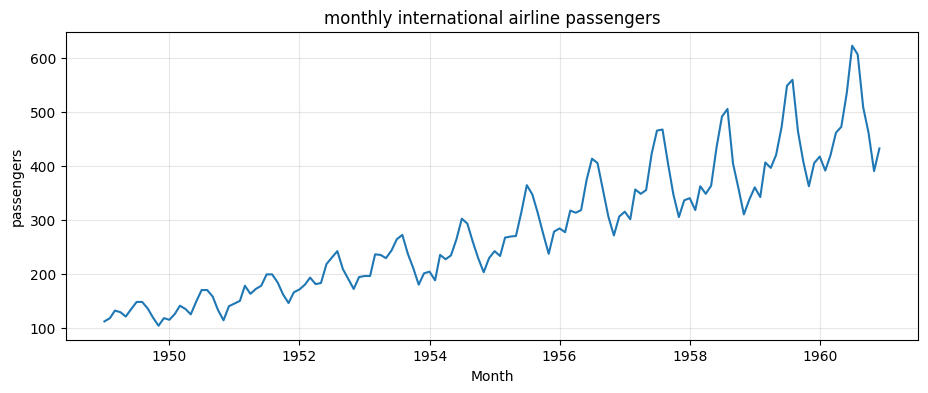

In [5]:
plt.figure(figsize=(11,4))
plt.plot(df["Month"],df["Passengers"])
plt.title("monthly international airline passengers")
plt.xlabel("Month")
plt.ylabel("passengers")
plt.grid(alpha=0.3)
plt.show()

**Prepare The Time Series**

We Use an 80:20 chronological split. The scaler is fitted only on training data to avoid future-data leakage

## 6] prepare the time series

In [6]:
LOOKBACK=12
values=df["Passengers"].values.reshape(-1,1).astype("float32")
train_size=int(len(values)*0.8)

scaler=MinMaxScaler()
scaler.fit(values[:train_size])
scaled=scaler.transform(values)

def make_sequences(data,start,end,lookback):
    x,y,idx=[],[],[]
    for i in range(start,end):
        x.append(data[i-lookback:i])
        y.append(data[i])
        idx.append(i)
    return np.array(x),np.array(y),np.array(idx)

x_train,y_train,_=make_sequences(scaled,LOOKBACK,train_size,LOOKBACK)
x_test,y_test,test_idx=make_sequences(scaled,train_size,len(scaled),LOOKBACK)

print("x train:",x_train.shape)
print("x test :",x_test.shape)

x train: (103, 12, 1)
x test : (29, 12, 1)


Build the RNN

## 7] build the RNN model

In [7]:
rnn=Sequential([
    Input(shape=(LOOKBACK,1)),
    SimpleRNN(32,activation="tanh"),
    Dense(1)
])
rnn.compile(optimizer="adam",loss="mse")
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## 8] build the LSTM model

In [8]:
lstm=Sequential([
    Input(shape=(LOOKBACK,1)),
    LSTM(32),
    Dense(1)
])
lstm.compile(optimizer="adam",loss="mse")
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Train Both Model

## 9] train the models

In [9]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

rnn_hist=rnn.fit(
    x_train,y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

lstm_hist=lstm.fit(
    x_train,y_train,
    epochs=500,
    batch_size=8,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

print("training completed")

training completed


## 10] compare model performance

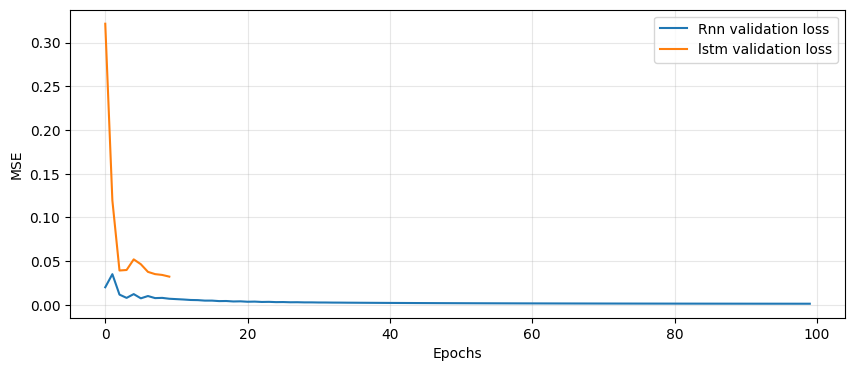

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_hist.history["val_loss"],label="Rnn validation loss")
plt.plot(lstm_hist.history["val_loss"],label="lstm validation loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11] make predictions

In [11]:
rnn_pred=scaler.inverse_transform(rnn.predict(x_test,verbose=0)).flatten()
lstm_pred=scaler.inverse_transform(lstm.predict(x_test,verbose=0)).flatten()
actual=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

def metrics(y,p):
    return[
        mean_absolute_error(y,p),
        np.sqrt(mean_squared_error(y,p)),
        mean_absolute_percentage_error(y,p)*100
    ]

rnn_m=metrics(actual,rnn_pred)
lstm_m=metrics(actual,lstm_pred)

result=pd.DataFrame({
    "Model":["simple rnn","lstm"],
    "mae":[rnn_m[0],lstm_m[0]],
    "rmse":[rnn_m[1],lstm_m[1]],
    "mape":[rnn_m[2],lstm_m[2]],
    "parameter":[rnn.count_params(),lstm.count_params()]
})

display(result.round(3))
best=result.loc[result["rmse"].idxmin(),"Model"]
print("best model by rmse :",best)

,Model,mae,rmse,mape,parameter
0,simple rnn,27.076,34.020,5.818,1121
1,lstm,262.254,274.034,58.299,4385


best model by rmse : simple rnn


## 12] evaluate the models

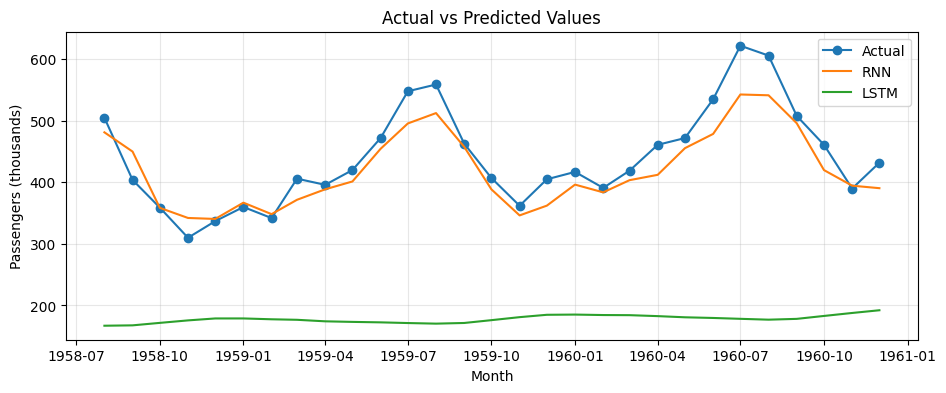

In [12]:
dates = df["Month"].iloc[test_idx]

plt.figure(figsize=(11,4))
plt.plot(dates, actual, label="Actual", marker="o")
plt.plot(dates, rnn_pred, label="RNN")
plt.plot(dates, lstm_pred, label="LSTM")
plt.title("Actual vs Predicted Values")
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13] visualize actual vs predicted values

In [13]:
def future_forecast(model, data, steps=12):
    window = data[-LOOKBACK:]
    out = []

    for _ in range(steps):
        x = window.reshape(1, LOOKBACK, 1)
        pred = model.predict(x, verbose=0)[0, 0]
        out.append(pred)
        window = np.vstack((window[1:], [[pred]]))

    return scaler.inverse_transform(np.array(out).reshape(-1, 1)).flatten()


STEPS = 12
rnn_future = future_forecast(rnn, scaled, STEPS)
lstm_future = future_forecast(lstm, scaled, STEPS)

future_dates = pd.date_range(
    df["Month"].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=STEPS,
    freq="MS"
)

future=pd.DataFrame({
    "Month":future_dates,
    "RNN forecast":rnn_future,
    "LSTM forecast":lstm_future
})

display(future.round(2))

,Month,RNN forecast,LSTM forecast
0,1961-01-01,435.000000,192.610001
1,1961-02-01,394.149994,197.149994
2,1961-03-01,412.179993,195.880005
3,1961-04-01,431.140015,190.820007
4,1961-05-01,459.679993,184.000000
5,1961-06-01,502.329987,176.800003
6,1961-07-01,548.659973,169.580002
7,1961-08-01,534.770020,162.630005
8,1961-09-01,500.010010,156.770004
9,1961-10-01,456.420013,152.339996


## 14] forecast future values

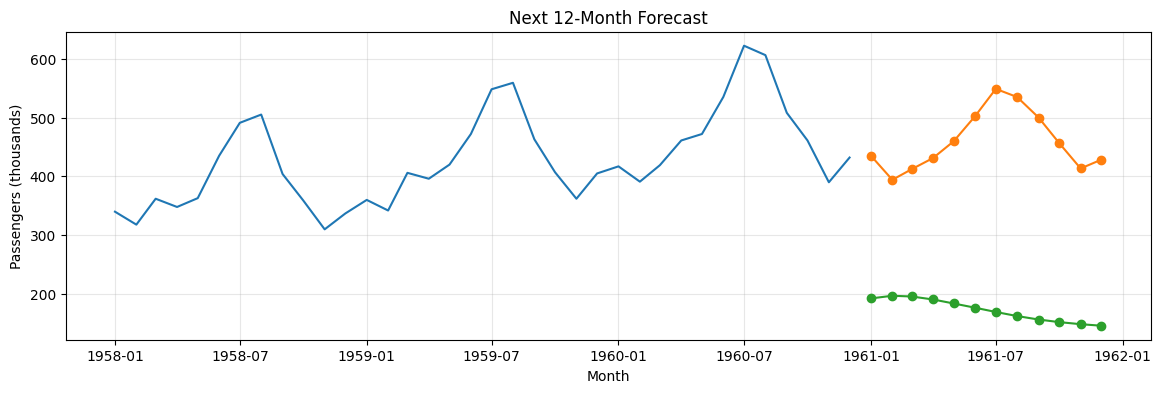

In [14]:
plt.figure(figsize=(14,4))

plt.plot(df["Month"].iloc[-36:], df["Passengers"].iloc[-36:], label="Historical")
plt.plot(future["Month"], future["RNN forecast"], marker="o", label="RNN Forecast")
plt.plot(future["Month"], future["LSTM forecast"], marker="o", label="LSTM Forecast")

plt.title("Next 12-Month Forecast")
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")

plt.grid(alpha=0.3)
plt.show()

***